# 02 — Four-agent consensus

First real use of the package: four double integrators, a cycle graph, rendezvous (all formation offsets zero). Establishes that the distributed solution matches the centralised one before any formation geometry is introduced.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from distributed_mpc_admm import plotting

plotting.apply_style("notebook")
rng = np.random.default_rng(0)

## Setup

Four agents scattered in a 10 m box, `dt = 0.1 s`, `T = 15`, cycle topology.

Text(0.5, 1.0, 'Cycle topology, scattered initial positions')

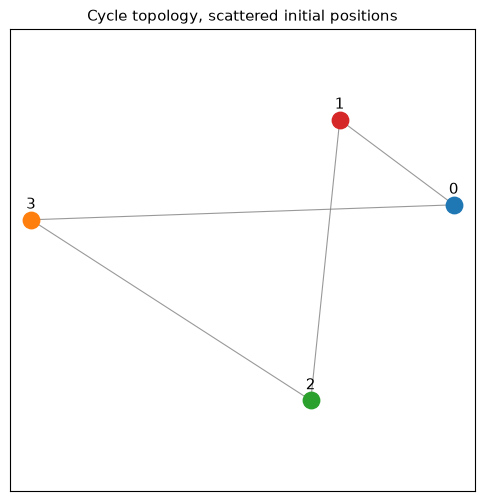

In [2]:
from distributed_mpc_admm.communication_graph import CommunicationGraph
from distributed_mpc_admm.formation_constraints import FormationSpec
from distributed_mpc_admm.per_agent_solver import (
    AgentCostWeights,
    AgentLimits,
    CvxpyAgentSolver,
    DoubleIntegrator,
)

model = DoubleIntegrator(dt=0.1, dim=2)
graph = CommunicationGraph.cycle(4)
formation = FormationSpec.rendezvous(4, graph)
limits = AgentLimits(u_max=3.0, v_max=2.0)
weights = AgentCostWeights()

# Scatter the agents gently (same generator as the test suite's _random_x0).
x0 = rng.normal(size=(4, model.n_states))
x0[:, model.dim :] *= 0.5

ax = plotting.plot_graph(graph, x0[:, : model.dim])
ax.set_title("Cycle topology, scattered initial positions")

## One open-loop ADMM solve

Run `ConsensusADMM.solve` once from the initial state and look at the residuals.

converged: True in 724 iterations
final primal residual: 3.516e-05
final dual residual:   8.303e-07
solve time:            7.352 s


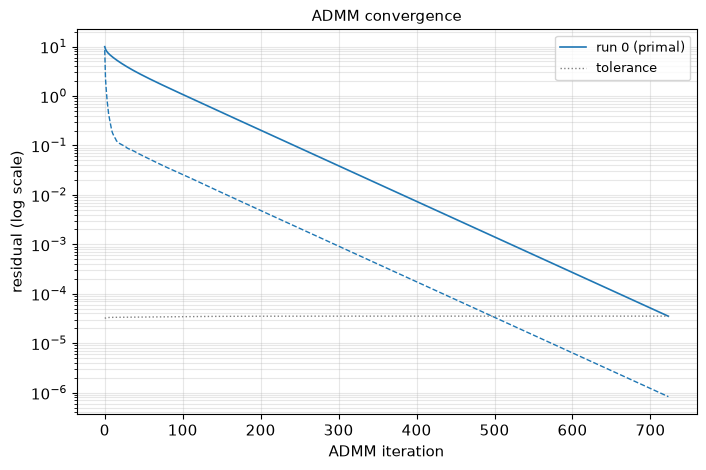

In [3]:
from distributed_mpc_admm import ADMMOptions, ConsensusADMM

horizon = 15

# Bake the (all-zero) rendezvous offsets into each agent's local QP.
solvers = {
    i: CvxpyAgentSolver(
        agent_id=i,
        horizon=horizon,
        model=model,
        limits=limits,
        weights=weights,
        neighborhood=graph.closed_neighborhood(i),
        offsets={j: np.zeros(model.dim) for j in graph.closed_neighborhood(i)},
    )
    for i in range(4)
}

admm = ConsensusADMM(
    graph,
    solvers,
    horizon,
    dim=model.dim,
    options=ADMMOptions(rho=1.0, max_iterations=2000, eps_abs=1e-6, eps_rel=1e-6),
)
result = admm.solve(x0, references={i: np.zeros((horizon, model.dim)) for i in range(4)})

print(f"converged: {result.converged} in {result.iterations} iterations")
print(f"final primal residual: {result.history.primal_residual[-1]:.3e}")
print(f"final dual residual:   {result.history.dual_residual[-1]:.3e}")
print(f"solve time:            {result.solve_time:.3f} s")

plotting.plot_convergence(result.history, show_tolerances=True)
plt.show()

## Sanity check against the centralised QP

The number that makes everything else credible. Build the monolithic QP and compare stacked input vectors, not just objective values.

In [4]:
# Same monolithic QP as tests/test_admm_convergence.py::solve_centralized.
import cvxpy as cp


def solve_centralized(x0, graph, model, horizon, weights, limits, offsets):
    n_agents = graph.n_agents
    t_steps, dim = horizon, model.dim
    phi_p, gamma_p = model.position_prediction_matrices(horizon)
    phi_v, gamma_v = model.velocity_prediction_matrices(horizon)

    U = cp.Variable((n_agents, t_steps * dim))
    P = [phi_p @ x0[i] + gamma_p @ U[i] for i in range(n_agents)]
    V = [phi_v @ x0[i] + gamma_v @ U[i] for i in range(n_agents)]

    objective = 0.0
    constraints = []
    for i in range(n_agents):
        objective += weights.q_position * cp.sum_squares(P[i])
        objective += weights.p_terminal * cp.sum_squares(P[i][(t_steps - 1) * dim :])
        objective += weights.q_velocity * cp.sum_squares(V[i])
        objective += weights.r_input * cp.sum_squares(U[i])
        constraints.append(cp.abs(U[i]) <= limits.u_max)
        constraints.append(cp.abs(V[i]) <= limits.v_max)

    for i, neighbors in offsets.items():
        for j, d in neighbors.items():
            if j == i:
                continue
            d_full = np.tile(np.asarray(d, dtype=float), t_steps)
            objective += weights.w_formation * cp.sum_squares(P[i] - P[j] - d_full)

    problem = cp.Problem(cp.Minimize(objective), constraints)
    problem.solve(solver="OSQP", eps_abs=1e-6, eps_rel=1e-6, max_iter=100000)
    return np.asarray(U.value).reshape(n_agents, t_steps, dim)


offsets = {i: {j: np.zeros(model.dim) for j in graph.closed_neighborhood(i)} for i in range(4)}
u_central = solve_centralized(x0, graph, model, horizon, weights, limits, offsets)

max_err = np.max(np.abs(result.inputs - u_central))
print(f"max |u_admm - u_central| = {max_err:.3e}")
assert max_err < 1e-3, "distributed ADMM must reproduce the centralised optimum"

max |u_admm - u_central| = 1.457e-04


## Closed loop

Wrap it in `DistributedMPC` and run 100 steps.

{'mean_admm_iterations': 2.38, 'max_admm_iterations': 124.0, 'final_formation_error': 0.002197753927920879, 'settling_step': 17.0, 'total_solve_time': 3.1466133979829465, 'convergence_failures': 0.0}


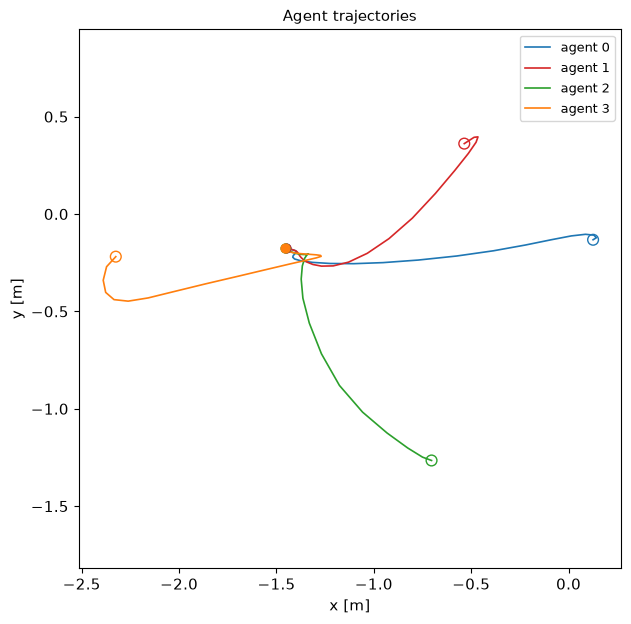

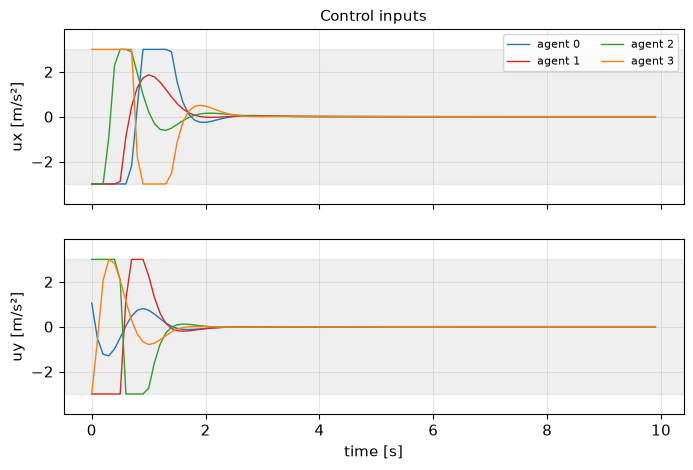

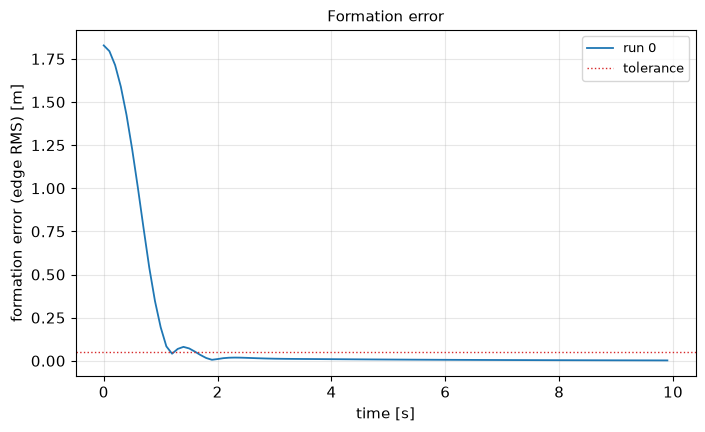

In [5]:
from distributed_mpc_admm import DistributedMPC, MPCOptions

# Rendezvous has no external reference: zero the tracking terms so the only
# coupling is the formation (spread-minimising) cost — same as the test suite.
rendezvous_weights = AgentCostWeights(q_position=0.0, p_terminal=0.0)

mpc = DistributedMPC(
    model,
    graph,
    formation,
    limits,
    rendezvous_weights,
    ADMMOptions(rho=1.0, max_iterations=300, eps_abs=2e-2, eps_rel=2e-2),
    MPCOptions(horizon=15, dt=0.1, n_steps=100, seed=0),
)
log = mpc.run(x0)

print(log.summary())
plotting.plot_trajectories(log, formation=formation)
plt.show()
plotting.plot_inputs(log, u_max=limits.u_max)
plt.show()
plotting.plot_formation_error(log, tolerance=0.05)
plt.show()

## Where the time goes

Per-iteration wall time split between local QPs and the averaging step.

ratio (local QP / z-update) = 22x


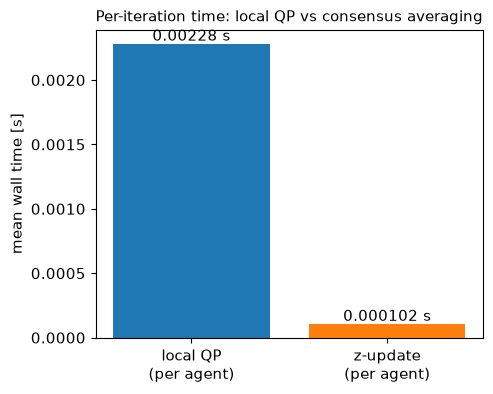

In [6]:
import time

# Time the two phases of one ADMM iteration separately (warm-started, steady state).
n_timing = 50
x_update_per_agent = []
z_update = []
for _ in range(n_timing):
    t0 = time.perf_counter()
    sols = admm._x_update(
        x0,
        {i: np.zeros((horizon, model.dim)) for i in range(4)},
        offsets,
        1.0,
    )
    t1 = time.perf_counter()
    admm._z = admm._z_update(admm._y, admm._lam, 0)
    t2 = time.perf_counter()
    x_update_per_agent.append((t1 - t0) / 4)
    z_update.append(t2 - t1)

mean_qp = np.mean(x_update_per_agent)
mean_z = np.mean(z_update)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["local QP\n(per agent)", "z-update\n(per agent)"],
    [mean_qp, mean_z],
    color=["tab:blue", "tab:orange"],
)
ax.bar_label(bars, fmt="%.3g s")
ax.set_ylabel("mean wall time [s]")
ax.set_title("Per-iteration time: local QP vs consensus averaging")
print(f"ratio (local QP / z-update) = {mean_qp / mean_z:.0f}x")
plt.show()

## C++ parity fixture

Export `cpp_admm/test/data/four_agent_reference.json`, the fixture the C++ kernel test replays. The schema is a contract (`python/scripts/generate_four_agent_reference.py` is the single source of truth): each iterate records the exact `(z_in, lam_in)` fed into an agent's QP and the `(U, y)` it returned, plus the converged `final_inputs`/`final_z`/`final_lam` for the optimum parity check.

In [7]:
import json
import subprocess
import sys
from pathlib import Path

import distributed_mpc_admm

# Drive the generator (single source of truth) and report what it wrote.
repo_root = Path(distributed_mpc_admm.__file__).resolve().parent.parent.parent
script = repo_root / "python" / "scripts" / "generate_four_agent_reference.py"
subprocess.run([sys.executable, str(script)], check=True)

fixture_path = repo_root / "cpp_admm" / "test" / "data" / "four_agent_reference.json"
fixture = json.loads(fixture_path.read_text())
print(f"exported {fixture_path.relative_to(repo_root)}")
print(f"  n_agents={fixture['n_agents']}  horizon={fixture['horizon']}  rho={fixture['rho']}")
print(f"  iterates={len(fixture['iterates'])}  converged={fixture['converged']}  "
      f"iterations_run={fixture['iterations_run']}")

wrote /repo/cpp_admm/test/data/four_agent_reference.json
converged=True iterations_run=1012 final_rho=1.0


exported cpp_admm/test/data/four_agent_reference.json
  n_agents=4  horizon=10  rho=1.0
  iterates=20  converged=True  iterations_run=1012


## Takeaway

Distributed ADMM reproduces the centralised optimum to solver tolerance, and the per-iteration cost is dominated by the local QP, not by communication.